In [ ]:
import os

# This should list your MyDrive contents without remounting
print(os.listdir("/content"))

['.config', 'test_FD001.txt', 'train_FD001.txt', 'RUL_FD001.txt', 'drive', 'sample_data']


In [ ]:
import os
project_path = "/content/drive/MyDrive/aircraft_rul_ensemble"  # <-- edit this
os.makedirs(project_path, exist_ok=True)
os.chdir(project_path)
print("Current working directory:", os.getcwd())

Current working directory: /content/drive/MyDrive/aircraft_rul_ensemble


In [ ]:
# Cell 1: Imports, seed, and file paths (fresh start)

import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import tensorflow as tf
from tensorflow.keras import layers, models, callbacks, optimizers

# For reproducibility
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)

set_seed(42)

# ==== FILE PATHS: adjust if needed ====
DATA_DIR = "/content"  # keep this if files are in /content

train_fp = os.path.join(DATA_DIR, "train_FD001.txt")
test_fp  = os.path.join(DATA_DIR, "test_FD001.txt")
rul_fp   = os.path.join(DATA_DIR, "RUL_FD001.txt")

print("Train:", train_fp)
print("Test :", test_fp)
print("RUL  :", rul_fp)


Train: /content/train_FD001.txt
Test : /content/test_FD001.txt
RUL  : /content/RUL_FD001.txt


In [ ]:
# Cell 2: Load CMAPSS FD001 and basic preprocessing

# Column names for FD001 (26 columns in train/test)
col_names = [
    "unit", "time",
    "op_1", "op_2", "op_3",
    "s_1", "s_2", "s_3", "s_4", "s_5",
    "s_6", "s_7", "s_8", "s_9", "s_10",
    "s_11", "s_12", "s_13", "s_14", "s_15",
    "s_16", "s_17", "s_18", "s_19", "s_20", "s_21"
]

train_df = pd.read_csv(train_fp, sep=r"\s+", header=None, names=col_names)
test_df  = pd.read_csv(test_fp,  sep=r"\s+", header=None, names=col_names)
rul_df   = pd.read_csv(rul_fp,   sep=r"\s+", header=None, names=["RUL"])

print("Train shape:", train_df.shape)
print("Test shape :", test_df.shape)
print("RUL shape  :", rul_df.shape)

# Drop columns that are constant in FD001 (standard choice in many works)
drop_cols = ["s_1", "s_5", "s_10", "s_16", "s_18", "s_19"]
train_df = train_df.drop(columns=drop_cols)
test_df  = test_df.drop(columns=drop_cols)

print("Train cols:", train_df.columns.tolist())
print("Test cols :", test_df.columns.tolist())


Train shape: (20631, 26)
Test shape : (13096, 26)
RUL shape  : (100, 1)
Train cols: ['unit', 'time', 'op_1', 'op_2', 'op_3', 's_2', 's_3', 's_4', 's_6', 's_7', 's_8', 's_9', 's_11', 's_12', 's_13', 's_14', 's_15', 's_17', 's_20', 's_21']
Test cols : ['unit', 'time', 'op_1', 'op_2', 'op_3', 's_2', 's_3', 's_4', 's_6', 's_7', 's_8', 's_9', 's_11', 's_12', 's_13', 's_14', 's_15', 's_17', 's_20', 's_21']


In [ ]:
# Cell 3: RUL labels, clipping, scaling, and feature list

MAX_RUL = 125          # common clipping value for FD001 in literature [web:19][web:22]
SEQUENCE_LENGTH = 70   # as per your earlier setup [web:28]

# 1) Compute RUL for train (countdown to failure within each unit)
train_rul = train_df.groupby("unit")["time"].max().reset_index()
train_rul.columns = ["unit", "max_time"]
train_df = train_df.merge(train_rul, on="unit", how="left")
train_df["RUL"] = train_df["max_time"] - train_df["time"]
train_df = train_df.drop(columns=["max_time"])

# Clip RUL
train_df["RUL"] = train_df["RUL"].clip(upper=MAX_RUL)

# 2) Compute RUL for test using provided RUL_FD001.txt
test_rul = test_df.groupby("unit")["time"].max().reset_index()
test_rul.columns = ["unit", "max_time"]

# rul_df rows correspond to test units in order [web:24]
test_rul["RUL_last"] = rul_df["RUL"].values
# RUL at each time step = RUL_last + (max_time - time)
test_df = test_df.merge(test_rul, on="unit", how="left")
test_df["RUL"] = test_df["RUL_last"] + (test_df["max_time"] - test_df["time"])
test_df = test_df.drop(columns=["max_time", "RUL_last"])

test_df["RUL"] = test_df["RUL"].clip(upper=MAX_RUL)

print(train_df[["unit", "time", "RUL"]].head())
print(test_df[["unit", "time", "RUL"]].head())

# 3) Define feature columns (exclude 'unit','time','RUL')
id_col = "unit"
time_col = "time"
target_col = "RUL"

feature_cols = [c for c in train_df.columns if c not in [id_col, time_col, target_col]]
final_feature_list = feature_cols

print("Number of features:", len(final_feature_list))
print("Features:", final_feature_list)

# 4) Scale features using training data only
scaler = StandardScaler()
train_df[final_feature_list] = scaler.fit_transform(train_df[final_feature_list])
test_df[final_feature_list]  = scaler.transform(test_df[final_feature_list])

# 5) Standardize target RUL for training (mean/std from train)
y_train_mean = train_df[target_col].mean()
y_train_std  = train_df[target_col].std()

train_df["RUL_std"] = (train_df[target_col] - y_train_mean) / y_train_std
test_df["RUL_std"]  = (test_df[target_col]  - y_train_mean) / y_train_std

print("y_train_mean:", y_train_mean)
print("y_train_std :", y_train_std)


   unit  time  RUL
0     1     1  125
1     1     2  125
2     1     3  125
3     1     4  125
4     1     5  125
   unit  time  RUL
0     1     1  125
1     1     2  125
2     1     3  125
3     1     4  125
4     1     5  125
Number of features: 18
Features: ['op_1', 'op_2', 'op_3', 's_2', 's_3', 's_4', 's_6', 's_7', 's_8', 's_9', 's_11', 's_12', 's_13', 's_14', 's_15', 's_17', 's_20', 's_21']
y_train_mean: 86.82928602588338
y_train_std : 41.67369885453619


In [ ]:
# Cell 4: Build sequences (X_tr, X_val, X_test_last, etc.)

SEQUENCE_LENGTH = 70  # keep as planned

def make_sequences(df, seq_len, feature_cols, target_col_std, id_col="unit"):
    X_list, y_list = [], []
    for unit_id, unit_data in df.groupby(id_col):
        unit_data = unit_data.sort_values("time")
        values = unit_data[feature_cols].values
        targets = unit_data[target_col_std].values  # standardized RUL

        if len(unit_data) >= seq_len:
            for i in range(len(unit_data) - seq_len + 1):
                X_list.append(values[i:i+seq_len])
                y_list.append(targets[i+seq_len-1])
    return np.array(X_list, dtype=np.float32), np.array(y_list, dtype=np.float32)

# Train sequences
X_all, y_all_std = make_sequences(
    train_df,
    seq_len=SEQUENCE_LENGTH,
    feature_cols=final_feature_list,
    target_col_std="RUL_std",
    id_col="unit"
)

print("X_all shape     :", X_all.shape)
print("y_all_std shape :", y_all_std.shape)

# Simple train/val split at engine level to avoid leakage
unit_ids = train_df["unit"].unique()
np.random.shuffle(unit_ids)

val_ratio = 0.2
n_val_units = int(len(unit_ids) * val_ratio)
val_units = set(unit_ids[:n_val_units])
train_units = set(unit_ids[n_val_units:])

def split_by_units(X, y, df, seq_len, val_units_set, id_col="unit"):
    X_tr_list, y_tr_list, X_val_list, y_val_list = [], [], [], []
    idx = 0
    for unit_id, unit_data in df.groupby(id_col):
        n_seq = max(0, len(unit_data) - seq_len + 1)
        if n_seq == 0:
            continue
        if unit_id in val_units_set:
            X_val_list.append(X[idx:idx+n_seq])
            y_val_list.append(y[idx:idx+n_seq])
        else:
            X_tr_list.append(X[idx:idx+n_seq])
            y_tr_list.append(y[idx:idx+n_seq])
        idx += n_seq

    X_tr = np.concatenate(X_tr_list, axis=0)
    y_tr = np.concatenate(y_tr_list, axis=0)
    X_val = np.concatenate(X_val_list, axis=0)
    y_val = np.concatenate(y_val_list, axis=0)
    return X_tr, y_tr, X_val, y_val

X_tr, y_tr_std, X_val, y_val_std = split_by_units(
    X_all, y_all_std, train_df, SEQUENCE_LENGTH, val_units
)

print("X_tr shape     :", X_tr.shape)
print("y_tr_std shape :", y_tr_std.shape)
print("X_val shape    :", X_val.shape)
print("y_val_std shape:", y_val_std.shape)

# Build last‑cycle sequences for test set (one per engine)
def make_last_cycle_sequences(df, seq_len, feature_cols, target_col, id_col="unit"):
    X_list, y_list = [], []
    for unit_id, unit_data in df.groupby(id_col):
        unit_data = unit_data.sort_values("time")
        values = unit_data[feature_cols].values
        targets = unit_data[target_col].values  # unstandardized RUL for final metric

        if len(unit_data) >= seq_len:
            X_list.append(values[-seq_len:])
            y_list.append(targets[-1])
        else:
            pad_len = seq_len - len(unit_data)
            pad_block = np.zeros((pad_len, values.shape[1]), dtype=np.float32)
            X_list.append(np.vstack([pad_block, values]))
            y_list.append(targets[-1])
    return np.array(X_list, dtype=np.float32), np.array(y_list, dtype=np.float32)

X_test_last, y_test_last = make_last_cycle_sequences(
    test_df,
    seq_len=SEQUENCE_LENGTH,
    feature_cols=final_feature_list,
    target_col="RUL",
    id_col="unit"
)

print("X_test_last shape:", X_test_last.shape)
print("y_test_last shape:", y_test_last.shape)


X_all shape     : (13731, 70, 18)
y_all_std shape : (13731,)
X_tr shape     : (11041, 70, 18)
y_tr_std shape : (11041,)
X_val shape    : (2690, 70, 18)
y_val_std shape: (2690,)
X_test_last shape: (100, 70, 18)
y_test_last shape: (100,)


In [ ]:
# Cell 5: Tuned v2 Transformer‑GRU (slightly smaller + more regularized)

import tensorflow as tf
from tensorflow.keras import layers, models, callbacks, optimizers
import numpy as np

SEQ_LEN = SEQUENCE_LENGTH
N_FEATS = X_tr.shape[2]

# TUNED v2 hyperparameters
d_model            = 40    # was 48
num_heads          = 4
ff_dim             = 80    # was 96
transformer_layers = 1
gru_units          = 40    # was 48
dropout_rate       = 0.35  # was 0.30
lr                 = 6e-4  # slightly smaller LR

print(f"Input shape: ({SEQ_LEN}, {N_FEATS})")

# Positional encoding
def positional_encoding(max_len, d_model):
    pos = np.arange(max_len)[:, np.newaxis]
    i = np.arange(d_model)[np.newaxis, :]
    angle_rates = 1 / np.power(10000, (2 * (i // 2)) / np.float32(d_model))
    angles = pos * angle_rates
    pe = np.zeros((max_len, d_model), dtype=np.float32)
    pe[:, 0::2] = np.sin(angles[:, 0::2])
    pe[:, 1::2] = np.cos(angles[:, 1::2])
    return tf.constant(pe[np.newaxis, ...])

pos_enc = positional_encoding(SEQ_LEN, d_model)

class AddPositionalEncoding(layers.Layer):
    def call(self, x):
        seq_len = tf.shape(x)[1]
        return x + pos_enc[:, :seq_len, :]

# Transformer block with L2
l2_reg = tf.keras.regularizers.l2(1e-4)

def transformer_block(x, d_model, num_heads, ff_dim, dropout_rate):
    attn_output = layers.MultiHeadAttention(
        num_heads=num_heads, key_dim=d_model,
        dropout=dropout_rate
    )(x, x)
    attn_output = layers.Dropout(dropout_rate)(attn_output)
    out1 = layers.LayerNormalization(epsilon=1e-6)(x + attn_output)

    ffn = layers.Dense(ff_dim, activation="relu", kernel_regularizer=l2_reg)(out1)
    ffn = layers.Dropout(dropout_rate)(ffn)
    ffn = layers.Dense(d_model, kernel_regularizer=l2_reg)(ffn)
    out2 = layers.LayerNormalization(epsilon=1e-6)(out1 + ffn)
    return out2

# Build model
inputs = layers.Input(shape=(SEQ_LEN, N_FEATS))
x = layers.Dense(d_model, kernel_regularizer=l2_reg)(inputs)
x = AddPositionalEncoding()(x)

for _ in range(transformer_layers):
    x = transformer_block(x, d_model, num_heads, ff_dim, dropout_rate)

x = layers.GRU(
    gru_units,
    return_sequences=False,
    dropout=dropout_rate,
    recurrent_dropout=0.1,
    kernel_regularizer=l2_reg,
)(x)

x = layers.Dense(64, activation="relu", kernel_regularizer=l2_reg)(x)
x = layers.Dropout(dropout_rate)(x)
x = layers.Dense(32, activation="relu", kernel_regularizer=l2_reg)(x)
outputs = layers.Dense(1, activation="linear")(x)

transformer_gru_model = models.Model(
    inputs=inputs,
    outputs=outputs,
    name="TransformerGRU_RUL_tuned_v2"
)
transformer_gru_model.summary()

# Targets shape
if y_tr_std.ndim == 1:
    y_tr_std = y_tr_std.reshape(-1, 1)
if y_val_std.ndim == 1:
    y_val_std = y_val_std.reshape(-1, 1)

# Compile
transformer_gru_model.compile(
    optimizer=optimizers.Adam(learning_rate=lr),
    loss="mse",
    metrics=["mae"]
)

# Callbacks (tighter ES)
es_cb = callbacks.EarlyStopping(
    monitor="val_loss",
    patience=8,            # was 12
    restore_best_weights=True,
    mode="min",
    verbose=1
)

ckpt_cb = callbacks.ModelCheckpoint(
    "transformer_gru_fd001_tuned_v2.weights.h5",
    monitor="val_loss",
    save_best_only=True,
    save_weights_only=True,
    mode="min",
    verbose=1
)

BATCH_SIZE = 256
EPOCHS = 200  # more allowed epochs; ES will stop earlier

history_tgru = transformer_gru_model.fit(
    X_tr, y_tr_std,
    validation_data=(X_val, y_val_std),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[es_cb, ckpt_cb],
    verbose=1
)

print("Best validation MAE (standardized RUL):", min(history_tgru.history["val_mae"]))


Input shape: (70, 18)


Model: "TransformerGRU_RUL_tuned_v2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_7       │ (None, 70, 18)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_22 (Dense)    │ (None, 70, 40)    │        760 │ input_layer_7[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_positional_enc… │ (None, 70, 40)    │          0 │ dense_22[0][0]    │
│ (AddPositionalEnco… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 70, 40)    │     26,120 │ add_positional_e… │
│ (MultiHeadAttentio… │                   │            │ add_positional_e… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_21          │ (None, 70, 40)    │          0 │ multi_head_atten… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_4 (Add)         │ (None, 70, 40)    │          0 │ add_positional_e… │
│                     │                   │            │ dropout_21[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 70, 40)    │         80 │ add_4[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_23 (Dense)    │ (None, 70, 80)    │      3,280 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_22          │ (None, 70, 80)    │          0 │ dense_23[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_24 (Dense)    │ (None, 70, 40)    │      3,240 │ dropout_22[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_5 (Add)         │ (None, 70, 40)    │          0 │ layer_normalizat… │
│                     │                   │            │ dense_24[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 70, 40)    │         80 │ add_5[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gru_4 (GRU)         │ (None, 40)        │      9,840 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_25 (Dense)    │ (None, 64)        │      2,624 │ gru_4[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_23          │ (None, 64)        │          0 │ dense_25[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_26 (Dense)    │ (None, 32)        │      2,080 │ dropout_23[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_27 (Dense)    │ (None, 1)         │         33 │ dense_26[0][0]    │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 48,137 (188.04 KB)

 Trainable params: 48,137 (188.04 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/200
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 302ms/step - loss: 0.7473 - mae: 0.6945
Epoch 1: val_loss improved from inf to 0.20181, saving model to transformer_gru_fd001_tuned_v2.weights.h5
44/44 ━━━━━━━━━━━━━━━━━━━━ 27s 362ms/step - loss: 0.7426 - mae: 0.6920 - val_loss: 0.2018 - val_mae: 0.3212
Epoch 2/200
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 318ms/step - loss: 0.2898 - mae: 0.4190
Epoch 2: val_loss improved from 0.20181 to 0.12854, saving model to transformer_gru_fd001_tuned_v2.weights.h5
44/44 ━━━━━━━━━━━━━━━━━━━━ 15s 343ms/step - loss: 0.2893 - mae: 0.4186 - val_loss: 0.1285 - val_mae: 0.2484
Epoch 3/200
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 252ms/step - loss: 0.2156 - mae: 0.3512
Epoch 3: val_loss improved from 0.12854 to 0.12298, saving model to transformer_gru_fd001_tuned_v2.weights.h5
44/44 ━━━━━━━━━━━━━━━━━━━━ 12s 276ms/step - loss: 0.2154 - mae: 0.3511 - val_loss: 0.1230 - val_mae: 0.2371
Epoch 4/200
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 252ms/step - loss: 0.1808 - mae: 0.3170
Epoch 4: val_loss impr

85/85 ━━━━━━━━━━━━━━━━━━━━ 5s 53ms/step
Validation RMSE (RUL): 12.261
Validation MAE  (RUL): 9.914
Validation R²        : 0.9082
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step

Test (last‑cycle) metrics:
Test RMSE (RUL): 13.477
Test MAE  (RUL): 11.012
Test R²        : 0.8869

Transformer-GRU (Model D v2)  (Threshold: RUL <= 40 as positive)
  Accuracy : 0.970
  Precision: 1.000
  Recall   : 0.893
  F1-score : 0.943

Confusion matrix:


,Pred 0,Pred 1
True 0 (healthy),72,0
True 1 (soon fail),3,25


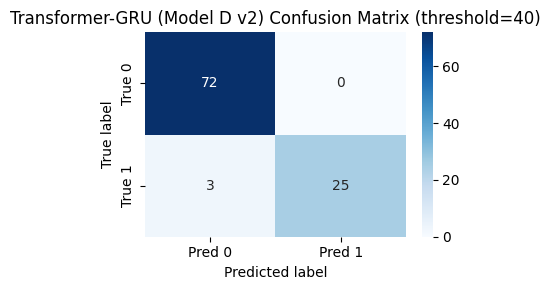

In [ ]:
# Cell 6: Compute validation + test metrics (real RUL) for Transformer‑GRU v2

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.metrics import (
    precision_score, recall_score, f1_score,
    confusion_matrix, accuracy_score
)

# Validation predictions
y_val_pred_std = transformer_gru_model.predict(X_val).reshape(-1)
y_val_true_std = y_val_std.reshape(-1)

y_val_pred = y_val_pred_std * y_train_std + y_train_mean
y_val_true = y_val_true_std * y_train_std + y_train_mean

val_rmse = np.sqrt(mean_squared_error(y_val_true, y_val_pred))
val_mae  = mean_absolute_error(y_val_true, y_val_pred)
val_r2   = r2_score(y_val_true, y_val_pred)

print(f"Validation RMSE (RUL): {val_rmse:.3f}")
print(f"Validation MAE  (RUL): {val_mae:.3f}")
print(f"Validation R²        : {val_r2:.4f}")

# Test predictions
y_test_pred_std = transformer_gru_model.predict(X_test_last).reshape(-1)
y_test_pred = y_test_pred_std * y_train_std + y_train_mean
y_test_true = y_test_last

test_rmse = np.sqrt(mean_squared_error(y_test_true, y_test_pred))
test_mae  = mean_absolute_error(y_test_true, y_test_pred)
test_r2   = r2_score(y_test_true, y_test_pred)

print("\nTest (last‑cycle) metrics:")
print(f"Test RMSE (RUL): {test_rmse:.3f}")
print(f"Test MAE  (RUL): {test_mae:.3f}")
print(f"Test R²        : {test_r2:.4f}")

def print_classification_metrics(name, y_true_rul, y_pred_rul, threshold=40):
    y_true_class = (y_true_rul <= threshold).astype(int)
    y_pred_class = (y_pred_rul <= threshold).astype(int)

    precision = precision_score(y_true_class, y_pred_class, zero_division=0)
    recall    = recall_score(y_true_class, y_pred_class, zero_division=0)
    f1        = f1_score(y_true_class, y_pred_class, zero_division=0)
    acc       = accuracy_score(y_true_class, y_pred_class)

    print(f"\n{name}  (Threshold: RUL <= {threshold} as positive)")
    print(f"  Accuracy : {acc:.3f}")
    print(f"  Precision: {precision:.3f}")
    print(f"  Recall   : {recall:.3f}")
    print(f"  F1-score : {f1:.3f}")

    cm = confusion_matrix(y_true_class, y_pred_class)
    cm_df = pd.DataFrame(
        cm,
        index=["True 0 (healthy)", "True 1 (soon fail)"],
        columns=["Pred 0", "Pred 1"]
    )
    print("\nConfusion matrix:")
    display(cm_df)

    plt.figure(figsize=(4, 3))
    sns.heatmap(
        cm, annot=True, fmt="d", cmap="Blues",
        xticklabels=["Pred 0", "Pred 1"],
        yticklabels=["True 0", "True 1"]
    )
    plt.title(f"{name} Confusion Matrix (threshold={threshold})")
    plt.ylabel("True label")
    plt.xlabel("Predicted label")
    plt.tight_layout()
    plt.show()

RUL_THRESHOLD = 40
print_classification_metrics(
    "Transformer-GRU (Model D v2)",
    y_test_last,
    y_test_pred,
    threshold=RUL_THRESHOLD
)


In [ ]:
save_dir = "/content/"  # adjust if needed
os.makedirs(save_dir, exist_ok=True)

# Weights-only file (light, good for loading into same code)
weights_path = os.path.join(save_dir, "transformer_gru_fd001_tuned_v2.weights.h5")
transformer_gru_model.save_weights(weights_path)
print("Saved weights to:", weights_path)

# Optional: full model (.keras) including architecture + weights
full_model_path = os.path.join(save_dir, "transformer_gru_fd001_tuned_v2.keras")
transformer_gru_model.save(full_model_path)
print("Saved full model to:", full_model_path)


Saved weights to: /content/transformer_gru_fd001_tuned_v2.weights.h5
Saved full model to: /content/transformer_gru_fd001_tuned_v2.keras


In [ ]:
import json

config = {
    "MAX_RUL": 125,
    "SEQUENCE_LENGTH": 70,
    "final_feature_list": final_feature_list,
    "y_train_mean": float(y_train_mean),
    "y_train_std": float(y_train_std),
}

config_path = os.path.join(save_dir, "fd001_transformer_gru_config_v2.json")
with open(config_path, "w") as f:
    json.dump(config, f, indent=2)

print("Saved config to:", config_path)


Saved config to: /content/fd001_transformer_gru_config_v2.json


In [ ]:
import joblib

scaler_path = os.path.join(save_dir, "fd001_scaler_v2.joblib")
joblib.dump(scaler, scaler_path)
print("Saved scaler to:", scaler_path)


Saved scaler to: /content/fd001_scaler_v2.joblib


In [ ]:
results_df = pd.DataFrame({
    "engine_id": np.arange(1, len(y_test_last)+1),
    "y_true": y_test_last,
    "y_pred_transformer_gru_v2": y_test_pred,
})

metrics = {
    "val_rmse": float(val_rmse),
    "val_mae": float(val_mae),
    "val_r2": float(val_r2),
    "test_rmse": float(test_rmse),
    "test_mae": float(test_mae),
    "test_r2": float(test_r2),
}

results_path = os.path.join(save_dir, "fd001_transformer_gru_v2_predictions.csv")
results_df.to_csv(results_path, index=False)
print("Saved predictions to:", results_path)

metrics_path = os.path.join(save_dir, "fd001_transformer_gru_v2_metrics.json")
with open(metrics_path, "w") as f:
    json.dump(metrics, f, indent=2)
print("Saved metrics to:", metrics_path)


Saved predictions to: /content/fd001_transformer_gru_v2_predictions.csv
Saved metrics to: /content/fd001_transformer_gru_v2_metrics.json


In [ ]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dropout, Dense, Bidirectional
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# For reproducibility
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)

set_seed(42)

# ==== FILE PATHS ====
DATA_DIR = "/content"

train_fp = os.path.join(DATA_DIR, "train_FD001.txt")
test_fp  = os.path.join(DATA_DIR, "test_FD001.txt")
rul_fp   = os.path.join(DATA_DIR, "RUL_FD001.txt")

print("Train:", train_fp)
print("Test :", test_fp)
print("RUL  :", rul_fp)


Train: /content/train_FD001.txt
Test : /content/test_FD001.txt
RUL  : /content/RUL_FD001.txt


In [ ]:
set_seed(42)

# 1) Load raw data with your column names
cols = ['Engine ID', 'Cycle',
        'Op Setting 1', 'Op Setting 2', 'Op Setting 3',
        'Sensor 1', 'Sensor 2', 'Sensor 3', 'Sensor 4', 'Sensor 5', 'Sensor 6',
        'Sensor 7', 'Sensor 8', 'Sensor 9', 'Sensor 10', 'Sensor 11', 'Sensor 12',
        'Sensor 13', 'Sensor 14', 'Sensor 15', 'Sensor 16', 'Sensor 17', 'Sensor 18',
        'Sensor 19', 'Sensor 20', 'Sensor 21']

# First, check if files exist locally, if not upload them
import os
from google.colab import files

if not os.path.exists('/content/train_FD001.txt'):
    print("📤 Files not found. Please upload them:")
    uploaded = files.upload()
    print("✓ Files uploaded")

# Now load the data
train_df = pd.read_csv('/content/train_FD001.txt', sep=r'\s+', header=None, names=cols, index_col=False)
test_df  = pd.read_csv('/content/test_FD001.txt',  sep=r'\s+', header=None, names=cols, index_col=False)

print("Train shape:", train_df.shape)
print("Test shape :", test_df.shape)

# 2) Build RUL for train (standard max_cycle - cycle)
max_cycle_df = train_df.groupby('Engine ID')['Cycle'].max().reset_index()
max_cycle_df.columns = ['Engine ID', 'Max Cycle']
train_df = train_df.merge(max_cycle_df, on='Engine ID', how='left')
train_df['RUL'] = train_df['Max Cycle'] - train_df['Cycle']
train_df.drop(columns=['Max Cycle'], inplace=True)

# 3) Read test RUL vector (last-cycle RUL per engine)
with open('/content/RUL_FD001.txt', 'r') as f:
    test_rul = np.array([int(line.strip()) for line in f.readlines()])

print("test_rul shape:", test_rul.shape)

# 4) Choose informative sensors and settings
selected_sensor_list = [
    'Sensor 2', 'Sensor 3', 'Sensor 4', 'Sensor 7', 'Sensor 8',
    'Sensor 9', 'Sensor 11', 'Sensor 12', 'Sensor 13',
    'Sensor 14', 'Sensor 15', 'Sensor 17', 'Sensor 20', 'Sensor 21'
]
selected_feature_list = ['Op Setting 1', 'Op Setting 2'] + selected_sensor_list
print("Base features:", selected_feature_list)
print("Base feature count:", len(selected_feature_list))

# 5) EWMA smoothing per engine (to capture trends)
def apply_ewma(df, feature_cols, window_size=20):
    df_temp = df.copy()
    for col in feature_cols:
        ewma_series = (
            df_temp
            .groupby('Engine ID')[col]
            .ewm(span=window_size, adjust=False)
            .mean()
            .reset_index(level=0, drop=True)
        )
        df_temp[f'EWMA_{col}'] = ewma_series
    return df_temp

train_df = apply_ewma(train_df, selected_feature_list, window_size=20)
test_df  = apply_ewma(test_df,  selected_feature_list, window_size=20)

final_feature_list = selected_feature_list + [f"EWMA_{col}" for col in selected_feature_list]
print("Final feature count (with EWMA):", len(final_feature_list))

# 6) Standardize features (fit on train, apply to both)
scaler = StandardScaler()
scaler.fit(train_df[final_feature_list])

train_df[final_feature_list] = scaler.transform(train_df[final_feature_list])
test_df[final_feature_list]  = scaler.transform(test_df[final_feature_list])

print("Feature scaling done.")
print("\nTrain preview:")
display(train_df[['Engine ID', 'Cycle', 'RUL'] + final_feature_list[:5]].head())


Train shape: (20631, 26)
Test shape : (13096, 26)
test_rul shape: (100,)
Base features: ['Op Setting 1', 'Op Setting 2', 'Sensor 2', 'Sensor 3', 'Sensor 4', 'Sensor 7', 'Sensor 8', 'Sensor 9', 'Sensor 11', 'Sensor 12', 'Sensor 13', 'Sensor 14', 'Sensor 15', 'Sensor 17', 'Sensor 20', 'Sensor 21']
Base feature count: 16
Final feature count (with EWMA): 32
Feature scaling done.

Train preview:


,Engine ID,Cycle,RUL,Op Setting 1,Op Setting 2,Sensor 2,Sensor 3,Sensor 4
0,1,1,191,-0.315980,-1.372953,-1.721725,-0.134255,-0.925936
1,1,2,190,0.872722,-1.031720,-1.061780,0.211528,-0.643726
2,1,3,189,-1.961874,1.015677,-0.661813,-0.413166,-0.525953
3,1,4,188,0.324090,-0.008022,-0.661813,-1.261314,-0.784831
4,1,5,187,-0.864611,-0.690488,-0.621816,-1.251528,-0.301518


In [ ]:
# Cell 3: Build sequences (SEQ_LEN=70) and standardize targets

set_seed(42)

SEQUENCE_LENGTH = 70

def create_sequences(df, sequence_length, feature_cols):
    X, y = [], []
    for engine_id, group in df.groupby('Engine ID'):
        group = group.sort_values('Cycle')
        data = group[feature_cols].values
        labels = group['RUL'].values
        clipped_labels = np.clip(labels, 0, 125)  # cap at 125
        if len(data) < sequence_length:
            continue
        for i in range(len(data) - sequence_length + 1):
            X.append(data[i:i + sequence_length])
            y.append(clipped_labels[i + sequence_length - 1])
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)

X_train, y_train = create_sequences(train_df, SEQUENCE_LENGTH, final_feature_list)

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("RUL stats (clipped):")
print(" min:", y_train.min(), " max:", y_train.max())

from sklearn.model_selection import train_test_split

X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train, test_size=0.15, random_state=42, shuffle=True
)

# Standardize targets based on training subset
y_train_mean = y_tr.mean()
y_train_std  = y_tr.std()

y_tr_std  = (y_tr - y_train_mean) / y_train_std
y_val_std = (y_val - y_train_mean) / y_train_std

print("\nTrain sequences:", X_tr.shape, " Val sequences:", X_val.shape)
print("Target mean:", y_train_mean, " std:", y_train_std)


X_train shape: (13731, 70, 32)
y_train shape: (13731,)
RUL stats (clipped):
 min: 0.0  max: 125.0

Train sequences: (11671, 70, 32)  Val sequences: (2060, 70, 32)
Target mean: 69.188156  std: 40.537743


In [ ]:
# Cell 4: Train a stronger BiLSTM on standardized RUL

set_seed(42)

model = Sequential([
    Bidirectional(
        LSTM(128, return_sequences=True),
        input_shape=(SEQUENCE_LENGTH, len(final_feature_list))
    ),
    Dropout(0.4),
    Bidirectional(LSTM(64, return_sequences=False)),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(1)  # standardized RUL
])

model.compile(
    optimizer=Adam(learning_rate=3e-4),
    loss='mse',
    metrics=['mae']
)

model.summary()

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=7,
    min_lr=1e-5,
    verbose=1
)

history = model.fit(
    X_tr, y_tr_std,
    validation_data=(X_val, y_val_std),
    epochs=140,
    batch_size=64,
    callbacks=[early_stop, reduce_lr],
    verbose=2
)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional (Bidirectional)   │ (None, 70, 256)        │       164,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 70, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 128)            │       164,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 337,537 (1.29 MB)

 Trainable params: 337,537 (1.29 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/140
183/183 - 11s - 59ms/step - loss: 0.2156 - mae: 0.3622 - val_loss: 0.0779 - val_mae: 0.2203 - learning_rate: 3.0000e-04
Epoch 2/140
183/183 - 4s - 20ms/step - loss: 0.0963 - mae: 0.2463 - val_loss: 0.0508 - val_mae: 0.1737 - learning_rate: 3.0000e-04
Epoch 3/140
183/183 - 4s - 21ms/step - loss: 0.0729 - mae: 0.2133 - val_loss: 0.0375 - val_mae: 0.1499 - learning_rate: 3.0000e-04
Epoch 4/140
183/183 - 4s - 22ms/step - loss: 0.0611 - mae: 0.1944 - val_loss: 0.0251 - val_mae: 0.1217 - learning_rate: 3.0000e-04
Epoch 5/140
183/183 - 3s - 17ms/step - loss: 0.0518 - mae: 0.1797 - val_loss: 0.0242 - val_mae: 0.1200 - learning_rate: 3.0000e-04
Epoch 6/140
183/183 - 4s - 21ms/step - loss: 0.0449 - mae: 0.1669 - val_loss: 0.0202 - val_mae: 0.1085 - learning_rate: 3.0000e-04
Epoch 7/140
183/183 - 3s - 19ms/step - loss: 0.0384 - mae: 0.1547 - val_loss: 0.0172 - val_mae: 0.0994 - learning_rate: 3.0000e-04
Epoch 8/140
183/183 - 3s - 17ms/step - loss: 0.0358 - mae: 0.1484 - val_loss: 0.01

In [ ]:
# Cell 5: Last-cycle per-engine evaluation on test set

set_seed(42)

# 1) Build last SEQUENCE_LENGTH window per engine from test_df
X_test_last = []
engine_ids_last = []

for engine_id, group in test_df.groupby('Engine ID'):
    group = group.sort_values('Cycle')
    last_window = group.iloc[-SEQUENCE_LENGTH:][final_feature_list].values
    if last_window.shape[0] == SEQUENCE_LENGTH:
        X_test_last.append(last_window)
        engine_ids_last.append(engine_id)

X_test_last = np.array(X_test_last, dtype=np.float32)
engine_ids_last = np.array(engine_ids_last)
print("X_test_last shape:", X_test_last.shape)
print("Number of engines used:", len(engine_ids_last))

# 2) Map Engine ID -> true last-cycle RUL from test_rul vector
engine_id_list = np.sort(test_df['Engine ID'].unique())
engine_to_rul = {eid: rul for eid, rul in zip(engine_id_list, test_rul)}

y_test_last = np.array([engine_to_rul[eid] for eid in engine_ids_last], dtype=np.float32)
print("y_test_last shape:", y_test_last.shape)

# 3) Predict standardized RUL and de-standardize
y_test_pred_std = model.predict(X_test_last).reshape(-1)
y_test_pred = y_test_pred_std * y_train_std + y_train_mean

# 4) Compute metrics
mse_last = mean_squared_error(y_test_last, y_test_pred)
rmse_last = np.sqrt(mse_last)
mae_last = mean_absolute_error(y_test_last, y_test_pred)
r2_last = r2_score(y_test_last, y_test_pred)

print(f"\nLast-cycle Test MSE:  {mse_last:.2f}")
print(f"Last-cycle Test RMSE: {rmse_last:.2f}")
print(f"Last-cycle Test MAE:  {mae_last:.2f}")
print(f"Last-cycle Test R²:   {r2_last:.3f}")


X_test_last shape: (86, 70, 32)
Number of engines used: 86
y_test_last shape: (86,)
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 164ms/step

Last-cycle Test MSE:  317.37
Last-cycle Test RMSE: 17.81
Last-cycle Test MAE:  12.87
Last-cycle Test R²:   0.810


Threshold: RUL <= 40 as positive class
Precision: 1.000
Recall:    0.964
F1-score:  0.982

Confusion matrix:


,Pred 0,Pred 1
True 0 (healthy),58,0
True 1 (soon fail),1,27


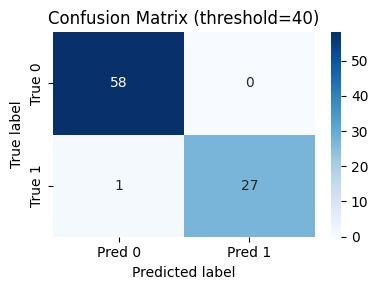

In [ ]:
# Cell: Classification metrics on last-cycle predictions

from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix

# Choose threshold for "fail soon" class
RUL_THRESHOLD = 40  # same as before; change if you want

# True and predicted classes
y_true_class = (y_test_last <= RUL_THRESHOLD).astype(int)
y_pred_class = (y_test_pred <= RUL_THRESHOLD).astype(int)

precision = precision_score(y_true_class, y_pred_class, zero_division=0)
recall    = recall_score(y_true_class, y_pred_class, zero_division=0)
f1        = f1_score(y_true_class, y_pred_class, zero_division=0)

print(f"Threshold: RUL <= {RUL_THRESHOLD} as positive class")
print(f"Precision: {precision:.3f}")
print(f"Recall:    {recall:.3f}")
print(f"F1-score:  {f1:.3f}")

# Confusion matrix
cm = confusion_matrix(y_true_class, y_pred_class)
cm_df = pd.DataFrame(
    cm,
    index=["True 0 (healthy)", "True 1 (soon fail)"],
    columns=["Pred 0", "Pred 1"]
)
print("\nConfusion matrix:")
display(cm_df)

plt.figure(figsize=(4, 3))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Pred 0", "Pred 1"],
            yticklabels=["True 0", "True 1"])
plt.title(f"Confusion Matrix (threshold={RUL_THRESHOLD})")
plt.ylabel("True label")
plt.xlabel("Predicted label")
plt.tight_layout()
plt.show()


In [ ]:
import tensorflow as tf
from tensorflow.keras.layers import Layer

class TemporalAttention(Layer):
    def __init__(self, **kwargs):
        super().__init__(**kwargs)

    def build(self, input_shape):
        self.W = self.add_weight(
            name="att_weight",
            shape=(input_shape[-1], 1),
            initializer="glorot_uniform",
            trainable=True
        )
        self.b = self.add_weight(
            name="att_bias",
            shape=(1,),
            initializer="zeros",
            trainable=True
        )
        super().build(input_shape)

    def call(self, inputs):
        # inputs: (batch, time, features)
        e = tf.keras.backend.tanh(tf.tensordot(inputs, self.W, axes=1) + self.b)  # (batch, time, 1)
        e = tf.keras.backend.squeeze(e, axis=-1)                                  # (batch, time)
        alpha = tf.keras.backend.softmax(e)                                       # (batch, time)
        alpha = tf.keras.backend.expand_dims(alpha, axis=-1)                      # (batch, time, 1)
        context = inputs * alpha                                                  # (batch, time, features)
        context = tf.keras.backend.sum(context, axis=1)                           # (batch, features)
        return context


In [ ]:
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (
    Input, Conv1D, MaxPooling1D, BatchNormalization,
    Bidirectional, LSTM, Dropout, Dense
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau


set_seed(123)


n_features = len(final_feature_list)


inp = Input(shape=(SEQUENCE_LENGTH, n_features))


# Multi-scale CNN block
x = Conv1D(filters=64, kernel_size=5, padding="same", activation="relu")(inp)
x = BatchNormalization()(x)
x = MaxPooling1D(pool_size=2)(x)


x = Conv1D(filters=128, kernel_size=3, padding="same", activation="relu")(x)
x = BatchNormalization()(x)
x = MaxPooling1D(pool_size=2)(x)


# BiLSTM encoding
x = Bidirectional(LSTM(64, return_sequences=True))(x)
x = Dropout(0.5)(x)


# Attention over time
x = TemporalAttention()(x)   # shape: (batch, features)


# Dense head
x = Dense(64, activation="relu")(x)
x = Dropout(0.4)(x)
out = Dense(1)(x)            # standardized RUL


model_att_cnn_bilstm = Model(inputs=inp, outputs=out)


model_att_cnn_bilstm.compile(
    optimizer=Adam(learning_rate=3e-4),
    loss="mse",
    metrics=["mae"]
)


model_att_cnn_bilstm.summary()


early_stop_B = EarlyStopping(
    monitor="val_loss",
    patience=15,
    restore_best_weights=True,
    verbose=1
)


reduce_lr_B = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=7,
    min_lr=1e-5,
    verbose=1
)


history_B = model_att_cnn_bilstm.fit(
    X_tr, y_tr_std,
    validation_data=(X_val, y_val_std),
    epochs=160,
    batch_size=64,
    callbacks=[early_stop_B, reduce_lr_B],
    verbose=2
)

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 70, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_4 (Conv1D)               │ (None, 70, 64)         │        10,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 70, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_4 (MaxPooling1D)  │ (None, 35, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_5 (Conv1D)               │ (None, 35, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 35, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_5 (MaxPooling1D)  │ (None, 17, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_4 (Bidirectional) │ (None, 17, 128)        │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 17, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ temporal_attention_2            │ (None, 128)            │           129 │
│ (TemporalAttention)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 143,042 (558.76 KB)

 Trainable params: 142,658 (557.26 KB)

 Non-trainable params: 384 (1.50 KB)

Epoch 1/160
183/183 - 7s - 38ms/step - loss: 0.2436 - mae: 0.3900 - val_loss: 0.1235 - val_mae: 0.2916 - learning_rate: 3.0000e-04
Epoch 2/160
183/183 - 3s - 16ms/step - loss: 0.1035 - mae: 0.2555 - val_loss: 0.0311 - val_mae: 0.1392 - learning_rate: 3.0000e-04
Epoch 3/160
183/183 - 8s - 42ms/step - loss: 0.0803 - mae: 0.2240 - val_loss: 0.0239 - val_mae: 0.1238 - learning_rate: 3.0000e-04
Epoch 4/160
183/183 - 4s - 21ms/step - loss: 0.0678 - mae: 0.2056 - val_loss: 0.0172 - val_mae: 0.1044 - learning_rate: 3.0000e-04
Epoch 5/160
183/183 - 4s - 19ms/step - loss: 0.0611 - mae: 0.1952 - val_loss: 0.0217 - val_mae: 0.1184 - learning_rate: 3.0000e-04
Epoch 6/160
183/183 - 2s - 13ms/step - loss: 0.0555 - mae: 0.1853 - val_loss: 0.0217 - val_mae: 0.1179 - learning_rate: 3.0000e-04
Epoch 7/160
183/183 - 3s - 16ms/step - loss: 0.0530 - mae: 0.1794 - val_loss: 0.0139 - val_mae: 0.0879 - learning_rate: 3.0000e-04
Epoch 8/160
183/183 - 2s - 12ms/step - loss: 0.0486 - mae: 0.1724 - val_loss: 0.010

In [ ]:
# Build last SEQUENCE_LENGTH window per engine from test_df
X_test_last = []
engine_ids_last = []

for engine_id, group in test_df.groupby('Engine ID'):
    group = group.sort_values('Cycle')
    last_window = group.iloc[-SEQUENCE_LENGTH:][final_feature_list].values
    if last_window.shape[0] == SEQUENCE_LENGTH:
        X_test_last.append(last_window)
        engine_ids_last.append(engine_id)

X_test_last = np.array(X_test_last, dtype=np.float32)
engine_ids_last = np.array(engine_ids_last)
print("X_test_last shape:", X_test_last.shape)
print("Number of engines used:", len(engine_ids_last))

# Map Engine ID -> true last-cycle RUL
engine_id_list = np.sort(test_df['Engine ID'].unique())
engine_to_rul = {eid: rul for eid, rul in zip(engine_id_list, test_rul)}
y_test_last = np.array([engine_to_rul[eid] for eid in engine_ids_last], dtype=np.float32)
print("y_test_last shape:", y_test_last.shape)


X_test_last shape: (86, 70, 32)
Number of engines used: 86
y_test_last shape: (86,)


In [ ]:
# Predict with attention CNN‑BiLSTM (Model B) only
y_pred_std_B = model_att_cnn_bilstm.predict(X_test_last).reshape(-1)
y_pred_B = y_pred_std_B * y_train_std + y_train_mean

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
mse_B = mean_squared_error(y_test_last, y_pred_B)
rmse_B = np.sqrt(mse_B)
mae_B  = mean_absolute_error(y_test_last, y_pred_B)
r2_B   = r2_score(y_test_last, y_pred_B)

print(f"Att‑CNN‑BiLSTM (Model B) RMSE: {rmse_B:.2f}")
print(f"Att‑CNN‑BiLSTM (Model B) MAE : {mae_B:.2f}")
print(f"Att‑CNN‑BiLSTM (Model B) R²  : {r2_B:.3f}")


3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 137ms/step
Att‑CNN‑BiLSTM (Model B) RMSE: 16.74
Att‑CNN‑BiLSTM (Model B) MAE : 13.38
Att‑CNN‑BiLSTM (Model B) R²  : 0.832


In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix

def print_classification_metrics(name, y_true_rul, y_pred_rul, threshold=40):
    # Binary labels from RUL
    y_true_class = (y_true_rul <= threshold).astype(int)
    y_pred_class = (y_pred_rul <= threshold).astype(int)

    precision = precision_score(y_true_class, y_pred_class, zero_division=0)
    recall    = recall_score(y_true_class, y_pred_class, zero_division=0)
    f1        = f1_score(y_true_class, y_pred_class, zero_division=0)

    print(f"\n{name}  (Threshold: RUL <= {threshold} as positive)")
    print(f"  Precision: {precision:.3f}")
    print(f"  Recall:    {recall:.3f}")
    print(f"  F1-score:  {f1:.3f}")

    cm = confusion_matrix(y_true_class, y_pred_class)
    cm_df = pd.DataFrame(
        cm,
        index=["True 0 (healthy)", "True 1 (soon fail)"],
        columns=["Pred 0", "Pred 1"]
    )
    print("\nConfusion matrix:")
    display(cm_df)

    plt.figure(figsize=(4, 3))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["Pred 0", "Pred 1"],
                yticklabels=["True 0", "True 1"])
    plt.title(f"{name} Confusion Matrix (threshold={threshold})")
    plt.ylabel("True label")
    plt.xlabel("Predicted label")
    plt.tight_layout()
    plt.show()


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step

Att-CNN-BiLSTM (Model B)  (Threshold: RUL <= 40 as positive)
  Precision: 1.000
  Recall:    0.857
  F1-score:  0.923

Confusion matrix:


,Pred 0,Pred 1
True 0 (healthy),58,0
True 1 (soon fail),4,24


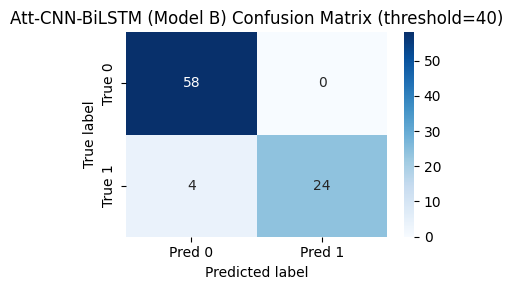

In [ ]:
# De-standardize Model B predictions to real RUL
y_test_pred_std_B = model_att_cnn_bilstm.predict(X_test_last).reshape(-1)
y_test_pred_B = y_test_pred_std_B * y_train_std + y_train_mean

# Classification metrics for Model B
RUL_THRESHOLD = 40  # or 30/50 if you want to experiment
print_classification_metrics(
    "Att-CNN-BiLSTM (Model B)",
    y_test_last,
    y_test_pred_B,
    threshold=RUL_THRESHOLD
)


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Bidirectional, Dropout, Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
import tensorflow as tf
import numpy as np

def set_seed(seed=1234):
    tf.keras.utils.set_random_seed(seed)
    tf.random.set_seed(seed)
    np.random.seed(seed)

set_seed(1234)

n_features = len(final_feature_list)

model_gru = Sequential([
    tf.keras.layers.Input(shape=(SEQUENCE_LENGTH, n_features)),
    Bidirectional(GRU(128, return_sequences=True)),
    Dropout(0.4),
    Bidirectional(GRU(64, return_sequences=False)),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(1)   # standardized RUL (same scaling as other models)
])

model_gru.compile(
    optimizer=Adam(learning_rate=3e-4),
    loss='mse',
    metrics=['mae']
)

ckpt_C = ModelCheckpoint(
    "gru_fd001_strong_v1.keras",
    monitor="val_loss",
    save_best_only=True,
    verbose=0
)

early_stop_C = EarlyStopping(
    monitor="val_loss",
    patience=20,
    restore_best_weights=True,
    verbose=1
)

reduce_lr_C = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=7,
    min_lr=1e-5,
    verbose=1
)

history_C = model_gru.fit(
    X_tr, y_tr_std,
    validation_data=(X_val, y_val_std),
    epochs=180,
    batch_size=64,
    callbacks=[ckpt_C, early_stop_C, reduce_lr_C],
    verbose=2
)


Epoch 1/180
183/183 - 7s - 36ms/step - loss: 0.2764 - mae: 0.4159 - val_loss: 0.1084 - val_mae: 0.2602 - learning_rate: 3.0000e-04
Epoch 2/180
183/183 - 4s - 22ms/step - loss: 0.1661 - mae: 0.3238 - val_loss: 0.0930 - val_mae: 0.2333 - learning_rate: 3.0000e-04
Epoch 3/180
183/183 - 3s - 17ms/step - loss: 0.1337 - mae: 0.2906 - val_loss: 0.0708 - val_mae: 0.2123 - learning_rate: 3.0000e-04
Epoch 4/180
183/183 - 3s - 17ms/step - loss: 0.1043 - mae: 0.2547 - val_loss: 0.0701 - val_mae: 0.2177 - learning_rate: 3.0000e-04
Epoch 5/180
183/183 - 3s - 17ms/step - loss: 0.0896 - mae: 0.2366 - val_loss: 0.0552 - val_mae: 0.1934 - learning_rate: 3.0000e-04
Epoch 6/180
183/183 - 4s - 22ms/step - loss: 0.0769 - mae: 0.2182 - val_loss: 0.0459 - val_mae: 0.1684 - learning_rate: 3.0000e-04
Epoch 7/180
183/183 - 3s - 16ms/step - loss: 0.0706 - mae: 0.2097 - val_loss: 0.0468 - val_mae: 0.1783 - learning_rate: 3.0000e-04
Epoch 8/180
183/183 - 3s - 17ms/step - loss: 0.0645 - mae: 0.1998 - val_loss: 0.039

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Standardized → original RUL for GRU (Model C)
y_pred_std_C = model_gru.predict(X_test_last).reshape(-1)
y_pred_C = y_pred_std_C * y_train_std + y_train_mean

mse_C = mean_squared_error(y_test_last, y_pred_C)
rmse_C = np.sqrt(mse_C)
mae_C  = mean_absolute_error(y_test_last, y_pred_C)
r2_C   = r2_score(y_test_last, y_pred_C)

print("GRU (Model C) – Last‑cycle Test")
print(f"  RMSE: {rmse_C:.2f}")
print(f"  MAE : {mae_C:.2f}")
print(f"  R²  : {r2_C:.3f}")


1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 264ms/step

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 141ms/step
GRU (Model C) – Last‑cycle Test
  RMSE: 16.53
  MAE : 12.19
  R²  : 0.836


In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix, accuracy_score

def print_gru_classification_metrics(y_true_rul, y_pred_rul, threshold=40):
    # Binary labels from RUL
    y_true_class = (y_true_rul <= threshold).astype(int)
    y_pred_class = (y_pred_rul <= threshold).astype(int)

    precision = precision_score(y_true_class, y_pred_class, zero_division=0)
    recall    = recall_score(y_true_class, y_pred_class, zero_division=0)
    f1        = f1_score(y_true_class, y_pred_class, zero_division=0)
    acc       = accuracy_score(y_true_class, y_pred_class)

    print(f"Threshold: RUL <= {threshold} as positive class")
    print(f"Accuracy : {acc:.3f}")
    print(f"Precision: {precision:.3f}")
    print(f"Recall   : {recall:.3f}")
    print(f"F1-score : {f1:.3f}")

    # Confusion matrix
    cm = confusion_matrix(y_true_class, y_pred_class)
    cm_df = pd.DataFrame(
        cm,
        index=["True 0 (healthy)", "True 1 (soon fail)"],
        columns=["Pred 0", "Pred 1"]
    )
    print("\nConfusion matrix:")
    display(cm_df)

    plt.figure(figsize=(4, 3))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["Pred 0", "Pred 1"],
                yticklabels=["True 0", "True 1"])
    plt.title(f"GRU Confusion Matrix (threshold={threshold})")
    plt.ylabel("True label")
    plt.xlabel("Predicted label")
    plt.tight_layout()
    plt.show()


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
Threshold: RUL <= 40 as positive class
Accuracy : 0.988
Precision: 1.000
Recall   : 0.964
F1-score : 0.982

Confusion matrix:


,Pred 0,Pred 1
True 0 (healthy),58,0
True 1 (soon fail),1,27


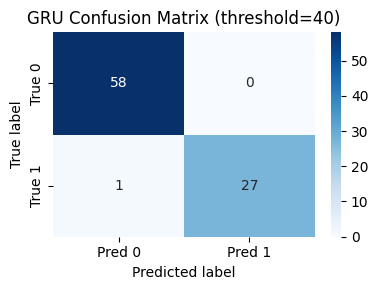

In [ ]:
# De-standardize GRU predictions
y_test_pred_std_C = model_gru.predict(X_test_last).reshape(-1)
y_test_pred_C = y_test_pred_std_C * y_train_std + y_train_mean

# Choose threshold
RUL_THRESHOLD = 40  # change if needed

# Compute metrics for GRU model
print_gru_classification_metrics(y_test_last, y_test_pred_C, threshold=RUL_THRESHOLD)
